# Specific Task 2.4 Train/Evaluate advanced model

In [1]:
import os, re, json, math, unicodedata, warnings
from collections import OrderedDict
from dataclasses import dataclass, asdict
from functools import partial
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# Reading Data

In [2]:
def read_txt(path):
    rows = []
    with open(path, "r", encoding="utf-8") as fh:
        lines = fh.read().splitlines()
    for line in lines:
        parts = line.split(": ")
        if len(parts) < 4:
            continue
        rows.append({
            "Event Type": parts[0].strip(),
            "Interaction": parts[1].strip(),
            "Feynman Diagram": parts[2].strip(),
            "Amplitude": parts[-2].strip(),
            "Squared Amplitude": parts[-1].strip()
        })
    return rows

In [3]:
base_dir = "/kaggle/input/datasets/arnavtripathi01/symba-test-data/SYMBA - Test Data"

qed_data = []
qcd_data = []

for file in os.listdir(base_dir):
    path = os.path.join(base_dir, file)
    rows = read_txt(path)
    if "QED" in file:
        qed_data.extend(rows)
    if "QCD" in file:
        qcd_data.extend(rows)

In [4]:
qed_df = pd.DataFrame(qed_data)
qcd_df = pd.DataFrame(qcd_data)

print("QED dataset size:", len(qed_df))
print("QCD dataset size:", len(qcd_df))

QED dataset size: 360
QCD dataset size: 234


# Train-Val-Test Split

In [5]:
from sklearn.model_selection import train_test_split

# split QED
qed_train, temp_df = train_test_split(qed_df, test_size=0.2, random_state=42, shuffle=True)
qed_val, qed_test = train_test_split(temp_df, test_size=0.5, random_state=42, shuffle=True)

# split QCD
qcd_train, temp_df = train_test_split(qcd_df, test_size=0.2, random_state=42, shuffle=True)
qcd_val, qcd_test = train_test_split(temp_df, test_size=0.5, random_state=42, shuffle=True)

print(f"QED -> Train size : {len(qed_train)}, Validation size : {len(qed_val)}, Test size : {len(qed_test)}")
print(f"QCD -> Train size : {len(qcd_train)}, Validation size : {len(qcd_val)}, Test size : {len(qcd_test)}")

qed_train.to_csv("qed_train.csv")
qed_val.to_csv("qed_val.csv")
qed_test.to_csv("qed_test.csv")

qcd_train.to_csv("qcd_train.csv")
qcd_val.to_csv("qcd_val.csv")
qcd_test.to_csv("qcd_test.csv")

QED -> Train size : 288, Validation size : 36, Test size : 36
QCD -> Train size : 187, Validation size : 23, Test size : 24


# Tokenizer

In [6]:
import json
from collections import Counter, OrderedDict
import re
import unicodedata
import warnings
from typing import List, Tuple, Dict, Any
from tqdm.auto import tqdm

class PittTokenizer:
    """Physics-informed tokenizer for amplitudes and squared amplitudes expressions."""
    def __init__(
        self,
        index_token_pool_size = 120,
        momentum_token_pool_size = 10,
        particle_index_pool_size = 10,
        special_symbols = None,
        unk_idx = 3
    ):
        self.index_pool_size = int(index_token_pool_size)
        self.momentum_pool_size = int(momentum_token_pool_size)
        self.particle_index_pool_size = int(particle_index_pool_size)
        self.index_tokens = [f"INDEX_{i}" for i in range(self.index_pool_size)]
        self.momentum_tokens = [f"MOMENTUM_{i}" for i in range(self.momentum_pool_size)]
        self.pindex_tokens = [f"PINDEX_{i}" for i in range(self.particle_index_pool_size)]
        self.special_symbols = special_symbols or ["<BOS>", "<PAD>", "<EOS>", "<UNK>", "<SEP>"]
        self.unk_idx = unk_idx

        # regex patterns
        self._re_whitespace = re.compile(r"\s+")
        self._re_unicode_norm = unicodedata.normalize
        self._re_gamma_token = re.compile(r'gamma_\{([^}]+)\}')
        self._re_wavefunction = re.compile(r'\b([A-Za-z]+)_\{([^}]+)\}\(([^)]+)\)(_[A-Za-z]+)(\^CONJ)?')
        self._re_momentum = re.compile(r'\bp_(\d+)\b')
        self._re_mandelstam = re.compile(r'\bs_(\d+)\b')
        self._re_mass = re.compile(r'\bm_[A-Za-z]+\b')
        self._re_particle_index = re.compile(r'\b([ijkl])_(\d+)\b')
        # candidate indices excluding mass/momentum/mandelstam/particle indices
        self._re_index_candidate = re.compile(r'(?!p_)(?!s_)(?!m_)(?![ijkl]_)[A-Za-z%\\]+_\d+')
        # operators and separators
        self._operators = list('/+-*^,{}()[]:=') 

    # ---- Normalization Utilities ----
    def normalize_unicode_and_whitespace(self, expression):
        """Apply unicode normalization and collapse whitespace."""
        if expression is None:
            return ""
        expr = self._re_unicode_norm("NFKC", expression)
        expr = self._re_whitespace.sub(" ", expr).strip()
        return expr

    def fix_brace_spaces(self, expr):
        """Canonicalize spacing inside {...} blocks:"""
        def clean(match):
            inner = match.group(1)
            inner = inner.strip()
            inner = re.sub(r'\s*,\s*', ',', inner)
            inner = re.sub(r'\s*\+\s*', '+', inner)
            inner = re.sub(r'\s*-\s*', '-', inner)
            return '{' + inner + '}'
        return re.sub(r'\{([^}]*)\}', clean, expr)

    def preprocess_expression(self, expression):
        """Canonicalize common physics tokens and simple formatting."""
        expr = self.normalize_unicode_and_whitespace(str(expression))
        expr = expr.replace("me", "m_e")
        expr = expr.replace("reg_prop", "REG_PROP")
        expr = expr.replace("(*)", "CONJ")
        expr = expr.replace("+-", "-").replace("-+", "-")
        expr = re.sub(r'\s*\*\s*', '*', expr)
        expr = re.sub(r'\s*/\s*', '/', expr)
        expr = re.sub(r'\s*\^\s*', '^', expr)
        expr = re.sub(r'\s*\+\s*', ' + ', expr)
        expr = re.sub(r'\s*-\s*', ' - ', expr)
        expr = re.sub(r'\s+', ' ', expr).strip()
        expr = self.fix_brace_spaces(expr)
        return expr

    def physics_aware_replace(self, expr):
        """Canonicalize momentum, mandelstam, masses, conjugation, imaginary unit and constants."""
        e = expr
        e = self._re_mandelstam.sub(r"MANDELSTAM_\1", e)
        e = self._re_momentum.sub(r"P_\1", e)
        e = self._re_mass.sub(lambda m: m.group(0), e)
        e = re.sub(r'\bi\b(?!\w)', 'I_UNIT', e)
        e = re.sub(r'\be\b(?=\^|[+\-*/()| ,])', 'E_CHARGE', e)
        e = re.sub(r'\bg\b(?=\^|[+\-*/()| ,])', 'G_COUPLING', e)
        return e

    # ---- Index Normalisation and Mapping ----
    def extract_pair_index_order(self, amp, sqamp):
        """Return ordered unique candidate indices, particle indices and momentum matches for a pair."""
        combined = amp + " || " + sqamp
        # find regular index candidates
        seen = OrderedDict()
        for m in self._re_index_candidate.finditer(combined):
            key = m.group(0)
            if key not in seen:
                seen[key] = None
        index_candidates = list(seen.keys())
        # particle indices
        pseen = OrderedDict()
        for m in self._re_particle_index.finditer(combined):
            key = m.group(0)
            if key not in pseen:
                pseen[key] = None
        particle_candidates = list(pseen.keys())
        # momentum occurrences
        mseen = OrderedDict()
        for m in self._re_momentum.finditer(combined):
            key = m.group(0)
            if key not in mseen:
                mseen[key] = None
        momentum_candidates = list(mseen.keys())

        return index_candidates, particle_candidates, momentum_candidates

    def build_deterministic_mapping(self, index_candidates, particle_candidates, momentum_candidates):
        """Create deterministic mapping to INDEX_/PINDEX_/MOMENTUM_ tokens."""
        mapping = {}
        for i, old in enumerate(index_candidates):
            if i >= self.index_pool_size:
                raise RuntimeError("index_pool exhausted; increase index_token_pool_size")
            mapping[old] = self.index_tokens[i]
        for i, old in enumerate(particle_candidates):
            if i >= self.particle_index_pool_size:
                raise RuntimeError("particle_index_pool exhausted; increase particle_index_pool_size")
            mapping[old] = self.pindex_tokens[i]
        for i, old in enumerate(momentum_candidates):
            if i >= self.momentum_pool_size:
                raise RuntimeError("momentum_pool exhausted; increase momentum_token_pool_size")
            mapping[old] = self.momentum_tokens[i]
        return mapping

    def apply_mapping_to_text(self, text, mapping):
        """Replace all full-token matches in text using provided mapping."""
        if not mapping:
            return text
        for old in sorted(mapping.keys(), key=len, reverse=True):
            new = mapping[old]
            text = text.replace(old, new)
        return text

    def normalize_pair_indices(self, ampl, sqamp):
        """Pre-processes and returns strictly mapped strings."""
        amp_p = self.preprocess_expression(ampl)
        sqamp_p = self.preprocess_expression(sqamp)
        idx_cands, p_cands, m_cands = self.extract_pair_index_order(amp_p, sqamp_p)
        mapping = self.build_deterministic_mapping(idx_cands, p_cands, m_cands)
        amp_mapped = self.apply_mapping_to_text(amp_p, mapping)
        sqamp_mapped = self.apply_mapping_to_text(sqamp_p, mapping)
        amp_final = self.physics_aware_replace(amp_mapped)
        sqamp_final = self.physics_aware_replace(sqamp_mapped)
        amp_final = self.fix_brace_spaces(amp_final)
        sqamp_final = self.fix_brace_spaces(sqamp_final)
        return amp_final, sqamp_final, mapping

    def normalize_dataframe_pairs(self, df, keep_mapping=False):
            """Applies normalization to dataframes."""
            records = []
            for _, row in tqdm(df.iterrows(), total=len(df), desc="Normalizing DataFrame Pairs"):
                ampl = row.get("Amplitude", "")
                sqamp = row.get("Squared Amplitude", "")
                ampl_norm, sqamp_norm, mapping = self.normalize_pair_indices(ampl, sqamp)
                rec = row.to_dict()
                rec["Amplitude_norm"] = ampl_norm
                rec["Squared_Amplitude_norm"] = sqamp_norm
                if keep_mapping:
                    rec["index_mapping"] = json.dumps(mapping)
                records.append(rec)
            return pd.DataFrame.from_records(records)
    
    # ---- Splitting Tokens ----
    def expand_structured_tokens(self, text):
        """Expand structured physics tokens by splitting their index/momentum arguments."""
        def _expand_gamma(m):
            inner = m.group(1)
            parts = [p.strip() for p in inner.split(',')]
            return f"GAMMA_{len(parts)} " + " , ".join(parts)
    
        def _expand_wavefunction(m):
            name  = m.group(1).upper()
            inner = m.group(2)
            mom   = m.group(3)
            vtype = m.group(4)
            conj  = " CONJ" if m.group(5) else ""
            parts = [p.strip() for p in inner.split(',')]
            return f"{name}_{len(parts)} " + " , ".join(parts) + f" {mom} {vtype}{conj}"
    
        text = self._re_wavefunction.sub(_expand_wavefunction, text)
        text = self._re_gamma_token.sub(_expand_gamma, text)
        text = re.sub(r'(MOMENTUM_\d+)_(INDEX_\d+)', r'\1 \2', text)
        return text
        
    def split_tokens(self, text):
        """Split on operators and keep tokens intelligible to transformer."""
        t = text
        for op in self._operators:
            t = t.replace(op, f' {op} ')
        # more frequent fractions kept intact
        top_fracs = ["1/2", "1/16", "1/9", "4/9", "1/448", "16/7", "1/144", "1/3", "1/6", "8/7"]
        for f in top_fracs:
            t = re.sub(rf"\b{f.replace('/', ' / ')}\b", f, t)
        t = re.sub(r'\s+', ' ', t).strip()
        tokens = [tok for tok in t.split(' ') if tok]
        return tokens

    def src_tokenize(self, ampl_norm):
        """Tokenize Source expression."""
        if not ampl_norm: return []
        try:
            expanded_str = self.expand_structured_tokens(str(ampl_norm))
            tokens = self.split_tokens(expanded_str)
            return tokens
        except Exception as e:
            warnings.warn(f"Source tokenization failed for '{ampl_norm}': {e}")
            return [self.special_symbols[self.unk_idx]]

    def tgt_tokenize(self, sqamp_norm):
        """Tokenize Target expression."""
        if not sqamp_norm: return []
        try:
            expanded_str = self.expand_structured_tokens(str(sqamp_norm))
            tokens = self.split_tokens(expanded_str)
            return tokens
        except Exception as e:
            warnings.warn(f"Target tokenization failed for '{sqamp_norm}': {e}")
            return [self.special_symbols[self.unk_idx]]

    # ---- Build Vocabularies ----
    def get_base_vocab(self):
        """Returns a set of index, momentum and pindex tokens."""
        base = set(self.special_symbols)
        base.update(self.index_tokens)
        base.update(self.momentum_tokens)
        base.update(self.pindex_tokens)
        return base

    def build_src_vocab(self, df: pd.DataFrame):
        """Build Source Vocabulary."""
        src_vocab = self.get_base_vocab()
        for s in tqdm(df["Amplitude_norm"].astype(str), total=len(df), desc="Building src vocab"):
            src_vocab.update(self.src_tokenize(s))
        return src_vocab

    def build_tgt_vocab(self, df: pd.DataFrame):
        """Build Target Vocabulary."""
        tgt_vocab = self.get_base_vocab()
        for s in tqdm(df["Squared_Amplitude_norm"].astype(str), total=len(df), desc="Building tgt vocab"):
            tgt_vocab.update(self.tgt_tokenize(s))
        return tgt_vocab

    def save_vocab(self, path, src_vocab, tgt_vocab):
        """Save Vocabularies to JSON file."""
        out = {
            "special_symbols": self.special_symbols,
            "src_vocab": sorted(list(src_vocab)),
            "tgt_vocab": sorted(list(tgt_vocab))
        }
        with open(path, "w", encoding="utf-8") as fh:
            json.dump(out, fh, ensure_ascii=False, indent=2)

    def load_vocab(self, path):
        """Load Vocabularies from JSON file."""
        with open(path, "r", encoding="utf-8") as fh:
            return json.load(fh)

In [7]:
class SymbolicVocab:
    """Simple vocab mapping between tokens and indices."""
    def __init__(self, tokens, special_symbols):
        remaining_tokens = sorted(list(set(tokens) - set(special_symbols)))
        self.token_list = special_symbols + remaining_tokens
        self.token_to_idx = {tok: i for i, tok in enumerate(self.token_list)}
        self.idx_to_token = {i: tok for tok, i in self.token_to_idx.items()}
        self.bos_idx = self.token_to_idx.get("<BOS>", 0)
        self.pad_idx = self.token_to_idx.get("<PAD>", 1)
        self.eos_idx = self.token_to_idx.get("<EOS>", 2)
        self.unk_idx = self.token_to_idx.get("<UNK>", 3)
        self.sep_idx = self.token_to_idx.get("<SEP>", 4)
        
    def encode(self, tokens):
        return [self.token_to_idx.get(tok, self.unk_idx) for tok in tokens]

    def decode(self, indices, include_special_tokens = True):
        if include_special_tokens:
            return [self.idx_to_token.get(i, "<UNK>") for i in indices]
        
        specials = {self.pad_idx, self.bos_idx, self.eos_idx, self.sep_idx}
        return [self.idx_to_token.get(i, "<UNK>") for i in indices if i not in specials]

    def __len__(self):
        return len(self.token_list)

# Architecture

In [8]:
@dataclass
class TitansConfig:
    """Hyperparameters for the Titans Encoder-MALDecoder model."""
    vocab_size:     int
    dim:            int   = 256
    depth:          int   = 6
    heads:          int   = 8
    dropout:        float = 0.1
    ffn_expansion:  float = 4.0
    mem_depth:      int   = 2
    mem_expansion:  float = 4.0
    mem_lr:         float = 0.01
    mem_momentum:   float = 0.9
    mem_decay:      float = 0.01
    mem_chunk_size: int   = 16
    pad_idx:        int   = 1

    def __post_init__(self):
        assert self.dim % self.heads == 0, 'dim must be divisible by heads'
        assert self.mem_chunk_size > 0,    'mem_chunk_size > 0 required'

    def to_dict(self): return asdict(self)

class RMSNorm(nn.Module):
    """Root-mean-square layer normalisation (no bias)."""
    def __init__(self, dim, eps = 1e-6):
        super().__init__()
        self.eps = eps
        self.g   = nn.Parameter(torch.ones(dim))
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.g


class SinusoidalPositionalEncoding(nn.Module):
    """Fixed sinusoidal positional encoding. """
    def __init__(self, d_model, dropout = 0.1, max_len = 2048):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float)
                        * (-math.log(10_000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x, offset = 0):
        return self.drop(x + self.pe[:, offset:offset + x.size(1)])

# Memory Module

In [9]:
# Neural Memory 
class NeuralMemoryMLP(nn.Module):
    """Small MLP whose weights constitute the memory state."""
    def __init__(self, dim, depth = 2, expansion = 4.0,
                 init_std: float = 0.02):
        super().__init__()
        H    = int(dim * expansion)
        dims = [dim] + [H] * (depth - 1) + [dim]
        self.layers   = nn.ModuleList(
            [nn.Linear(d_in, d_out, bias=False) for d_in, d_out in zip(dims[:-1], dims[1:])])
        self.n_layers = len(self.layers)
        for layer in self.layers:
            nn.init.normal_(layer.weight, std=init_std)

    def init_weights(self, device: torch.device) -> Dict[str, torch.Tensor]:
        """Return a fresh weight dict (detached clone) for memory state initialisation."""
        return {f'layers.{i}.weight': self.layers[i].weight.data.clone().to(device)
                for i in range(self.n_layers)}

    def forward_with_weights(self, x: torch.Tensor,
                             weight_dict: Dict[str, torch.Tensor]) -> torch.Tensor:
        """Forward pass using an external weight dict via functional_call."""
        from torch.func import functional_call
        return functional_call(self, weight_dict, (x,))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < self.n_layers - 1: x = F.silu(x)
        return x


class NeuralMemory(nn.Module):
    """Titans gradient-based neural memory with data-dependent gates."""
    def __init__(self, dim: int, depth: int = 2, expansion: float = 4.0,
                 base_lr: float = 0.01, base_momentum: float = 0.9, base_decay: float = 0.01):
        super().__init__()
        self.mlp           = NeuralMemoryMLP(dim, depth, expansion)
        self.to_k          = nn.Linear(dim, dim, bias=False)
        self.to_v          = nn.Linear(dim, dim, bias=False)
        self.to_q          = nn.Linear(dim, dim, bias=False)
        self.to_out        = nn.Linear(dim, dim, bias=False)
        self.norm_k        = RMSNorm(dim)
        self.norm_v        = RMSNorm(dim)
        self.norm_q        = RMSNorm(dim)
        self.gate_lr       = nn.Sequential(nn.Linear(dim, 1), nn.Sigmoid())
        self.gate_momentum = nn.Sequential(nn.Linear(dim, 1), nn.Sigmoid())
        self.gate_decay    = nn.Sequential(nn.Linear(dim, 1), nn.Sigmoid())
        self.base_lr       = base_lr
        self.base_momentum = base_momentum
        self.base_decay    = base_decay

    def init_state(self, device: torch.device) -> Dict:
        """Return a fresh (weights, momentum) state dict."""
        ws = self.mlp.init_weights(device)
        return {'weights': ws, 'momentum': {k: torch.zeros_like(v) for k, v in ws.items()}}

    def retrieve(self, x: torch.Tensor, state: Dict) -> torch.Tensor:
        """Query the memory: to_out(MLP_W(norm_q(to_q(x))))."""
        q = self.norm_q(self.to_q(x))
        return self.to_out(self.mlp.forward_with_weights(q, state['weights']))

    def update(self, x: torch.Tensor, state: Dict) -> Dict:
        """Update memory weights via associative-memory gradient descent."""
        k = self.norm_k(self.to_k(x))
        v = self.norm_v(self.to_v(x))

        ctx   = x.mean(dim=1, keepdim=True)
        theta = self.gate_lr(ctx).mean()       * self.base_lr
        eta   = self.gate_momentum(ctx).mean() * self.base_momentum
        alpha = self.gate_decay(ctx).mean()    * self.base_decay

        w_keys   = list(state['weights'].keys())
        w_leaves = [state['weights'][k_].detach().requires_grad_(True) for k_ in w_keys]
        w_dict   = dict(zip(w_keys, w_leaves))

        with torch.enable_grad():
            pred  = self.mlp.forward_with_weights(k, w_dict)
            loss  = F.mse_loss(pred, v)
            grads = torch.autograd.grad(loss, w_leaves, create_graph=True)  

        new_mom = {k_: eta * state['momentum'][k_] + (-g) for k_, g in zip(w_keys, grads)}
        new_wts = {k_: (1 - alpha) * state['weights'][k_] + theta * new_mom[k_]
                   for k_ in w_keys}
        return {'weights': new_wts, 'momentum': new_mom} 

# Attention Blocks & Helpers

In [10]:
class MultiHeadSelfAttention(nn.Module):
    """Multi-head self-attention."""
    def __init__(self, dim, n_heads, dropout = 0.0):
        super().__init__()
        assert dim % n_heads == 0
        self.n_heads = n_heads
        self.d_k     = dim // n_heads
        self.W_q     = nn.Linear(dim, dim, bias=False)
        self.W_k     = nn.Linear(dim, dim, bias=False)
        self.W_v     = nn.Linear(dim, dim, bias=False)
        self.W_o     = nn.Linear(dim, dim, bias=False)
        self.dropout = dropout

    def forward(self, x, attn_mask  = None, past_kv = None, use_cache = False):
        B, S, _ = x.shape
        h, dk   = self.n_heads, self.d_k

        def _split(t: torch.Tensor) -> torch.Tensor:
            return t.view(B, -1, h, dk).transpose(1, 2)

        q = _split(self.W_q(x))
        k = _split(self.W_k(x))
        v = _split(self.W_v(x))

        if past_kv is not None:
            past_k, past_v = past_kv
            k = torch.cat([past_k, k], dim=2) 
            v = torch.cat([past_v, v], dim=2)

        new_kv = (k, v) if use_cache else None

        out = F.scaled_dot_product_attention(
            q, k, v,
            attn_mask=attn_mask,
            dropout_p=self.dropout if self.training else 0.0,
        )
        return self.W_o(out.transpose(1, 2).reshape(B, S, h * dk)), new_kv


# Cross-Attention
class CrossAttention(nn.Module):
    """Multi-head cross-attention with optional encoder KV cache. """
    def __init__(self, dim, n_heads, dropout = 0.0):
        super().__init__()
        assert dim % n_heads == 0
        self.n_heads = n_heads
        self.d_k     = dim // n_heads
        self.W_q     = nn.Linear(dim, dim, bias=False)
        self.W_k     = nn.Linear(dim, dim, bias=False)
        self.W_v     = nn.Linear(dim, dim, bias=False)
        self.W_o     = nn.Linear(dim, dim, bias=False)
        self.dropout = dropout

    def forward(self, x, enc_out = None, attn_mask = None, enc_kv = None):
        B, St, _ = x.shape
        h, dk    = self.n_heads, self.d_k

        q = self.W_q(x).view(B, St, h, dk).transpose(1, 2)

        if enc_kv is not None:
            k, v = enc_kv
        else:
            assert enc_out is not None, "Either enc_out or enc_kv must be provided"
            k = self.W_k(enc_out).view(B, -1, h, dk).transpose(1, 2)
            v = self.W_v(enc_out).view(B, -1, h, dk).transpose(1, 2)

        out = F.scaled_dot_product_attention(
            q, k, v,
            attn_mask=attn_mask,
            dropout_p=self.dropout if self.training else 0.0,
        )
        return self.W_o(out.transpose(1, 2).reshape(B, St, h * dk)), (k, v)


#  Position-wise Feed-Forward Network
class FFN(nn.Module):
    """Standard 2-layer position-wise FFN with SiLU activation."""
    def __init__(self, dim, expansion = 4.0, dropout = 0.0):
        super().__init__()
        hidden = int(dim * expansion)
        self.net = nn.Sequential(
            nn.Linear(dim, hidden, bias=False),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim, bias=False),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# Attention masks
def make_causal_mask(tgt_len, device):
    return torch.tril(
        torch.ones(tgt_len, tgt_len, device=device, dtype=torch.bool)
    ).unsqueeze(0).unsqueeze(0)


def make_enc_self_mask(src_mask: torch.Tensor) -> torch.Tensor:
    """Bidirectional encoder self-attention mask from padding mask."""
    return src_mask.unsqueeze(1).unsqueeze(2)      


def make_cross_mask(src_mask: torch.Tensor) -> torch.Tensor:
    return src_mask.unsqueeze(1).unsqueeze(2)     

# Encdoer & Decoder with Memory As Layer

In [11]:
class MALDecoderBlock(nn.Module):
    """
    Titans MAL decoder block.
    Pipeline: Causal-SelfAttn -> FFN -> MAL-memory -> CrossAttn.
    """
    def __init__(self, cfg: TitansConfig):
        super().__init__()
        # causal self-attention
        self.norm1     = RMSNorm(cfg.dim)
        self.self_attn = MultiHeadSelfAttention(cfg.dim, cfg.heads, cfg.dropout)

        # standard FFN
        self.norm2 = RMSNorm(cfg.dim)
        self.ffn   = FFN(cfg.dim, cfg.ffn_expansion, cfg.dropout)

        # MAL neural memory (S4.3)
        self.norm_mem   = RMSNorm(cfg.dim)
        self.memory     = NeuralMemory(
            cfg.dim, cfg.mem_depth, cfg.mem_expansion,
            cfg.mem_lr, cfg.mem_momentum, cfg.mem_decay,
        )
        self.chunk_size = cfg.mem_chunk_size

        # cross-attention to encoder
        self.norm_cross = RMSNorm(cfg.dim)
        self.cross_attn = CrossAttention(cfg.dim, cfg.heads, cfg.dropout)

    def forward(self, x, mem_state, enc_out = None, tgt_mask = None,cross_mask = None,
                past_self_kv = None, enc_kv = None, use_cache= False):

        # Causal Self-Attention
        sa_out, new_self_kv = self.self_attn(
            self.norm1(x),
            attn_mask=tgt_mask,
            past_kv=past_self_kv,
            use_cache=use_cache,
        )
        x = x + sa_out

        # Feed-Forward Network
        x = x + self.ffn(self.norm2(x))

        # MAL -- Memory As a Layer
        z = self.norm_mem(x)
        
        out_chunks = []
        curr_mem_state = mem_state

        for z_chunk in z.split(self.chunk_size, dim=1): 
            r_chunk = self.memory.retrieve(z_chunk, curr_mem_state)
            out_chunks.append(r_chunk)

            curr_mem_state = self.memory.update(z_chunk, curr_mem_state)

        mal_out = torch.cat(out_chunks, dim=1)

        x = x + mal_out 
        
        new_mem_state = curr_mem_state 

        # Cross-Attention to Encoder
        ca_out, new_enc_kv = self.cross_attn(
            self.norm_cross(x),
            enc_out=enc_out if enc_kv is None else None,
            attn_mask=cross_mask,
            enc_kv=enc_kv,
        )
        x = x + ca_out

        return x, new_mem_state, new_self_kv, new_enc_kv

class EncoderBlock(nn.Module):
    def __init__(self, cfg: TitansConfig):
        super().__init__()
        self.norm1 = RMSNorm(cfg.dim)
        self.attn  = MultiHeadSelfAttention(cfg.dim, cfg.heads, cfg.dropout)
        self.norm2 = RMSNorm(cfg.dim)
        self.ffn   = FFN(cfg.dim, cfg.ffn_expansion, cfg.dropout)

    def forward(self, x: torch.Tensor,
                attn_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        attn_out, _ = self.attn(self.norm1(x), attn_mask=attn_mask)
        x = x + attn_out
        x = x + self.ffn(self.norm2(x))
        return x

class TransformerEncoder(nn.Module):
    """Stack of EncoderBlocks."""
    def __init__(self, cfg: TitansConfig):
        super().__init__()
        self.embed  = nn.Embedding(cfg.vocab_size, cfg.dim, padding_idx=cfg.pad_idx)
        self.pe     = SinusoidalPositionalEncoding(cfg.dim, cfg.dropout)
        self.layers = nn.ModuleList([EncoderBlock(cfg) for _ in range(cfg.depth)])
        self.norm   = RMSNorm(cfg.dim)
        self.scale  = math.sqrt(cfg.dim)
        nn.init.normal_(self.embed.weight, std=0.02)
        with torch.no_grad():
            self.embed.weight[cfg.pad_idx].fill_(0)

    def forward(self, src_ids, src_mask = None):
        enc_self_mask = make_enc_self_mask(src_mask) if src_mask is not None else None
        x = self.pe(self.embed(src_ids) * self.scale)
        for layer in self.layers:
            x = layer(x, attn_mask=enc_self_mask)
        return self.norm(x)

In [12]:
class TitansEncoderMALDecoder(nn.Module):
    """
    Full encoder-decoder model where every decoder block follows:
        Causal-SelfAttn -> FFN -> MAL-memory -> CrossAttn
    """
    def __init__(self, cfg: TitansConfig):
        super().__init__()
        self.cfg     = cfg
        self.encoder = TransformerEncoder(cfg)

        self.dec_embed = nn.Embedding(cfg.vocab_size, cfg.dim, padding_idx=cfg.pad_idx)
        self.dec_pe    = SinusoidalPositionalEncoding(cfg.dim, cfg.dropout)
        self.dec_scale = math.sqrt(cfg.dim)
        nn.init.normal_(self.dec_embed.weight, std=0.02)
        with torch.no_grad():
            self.dec_embed.weight[cfg.pad_idx].fill_(0)

        self.dec_layers = nn.ModuleList([MALDecoderBlock(cfg) for _ in range(cfg.depth)])
        self.dec_norm   = RMSNorm(cfg.dim)
        self.lm_head    = nn.Linear(cfg.dim, cfg.vocab_size, bias=False)

    def _init_mem_states(self, device: torch.device) -> List[Dict]:
        """Initialise a fresh NeuralMemory state for every decoder layer."""
        return [layer.memory.init_state(device) for layer in self.dec_layers]

    def forward(self, src_ids, tgt_ids, labels = None, src_mask = None):

        B, Ss = src_ids.shape
        St    = tgt_ids.shape[1]
        device = src_ids.device

        # -- Encode -----------------------------------------------------------
        enc_out = self.encoder(src_ids, src_mask=src_mask)  

        # -- Build decoder masks ---------------------------------------------
        tgt_mask   = make_causal_mask(St, device)            
        cross_mask = make_cross_mask(src_mask) if src_mask is not None else None

        # Combine causal mask with decoder padding
        if tgt_ids is not None:
            tgt_real  = (tgt_ids != self.cfg.pad_idx)         
            tgt_mask  = tgt_mask & tgt_real.unsqueeze(1).unsqueeze(3)

        # -- Decode ----------------------------------------------------------
        x          = self.dec_pe(self.dec_embed(tgt_ids) * self.dec_scale)
        mem_states = self._init_mem_states(device)

        for i, layer in enumerate(self.dec_layers):
            x, mem_states[i], _, _ = layer(
                x, mem_states[i], enc_out,
                tgt_mask=tgt_mask, cross_mask=cross_mask,
            )

        logits = self.lm_head(self.dec_norm(x))              

        if labels is None:
            return logits

        return F.cross_entropy(
            logits.reshape(-1, self.cfg.vocab_size),
            labels.reshape(-1),
            ignore_index=self.cfg.pad_idx,
        )

    # Greedy autoregressive decoding
    @torch.no_grad()
    def greedy_generate(
        self,
        src_ids:         torch.Tensor,
        bos_idx:         int,
        max_new_tokens:  int                    = 2024,
        eos_idx:         Optional[int]          = None,
        device:          Optional[torch.device] = None,
        tgt_logit_mask:  Optional[torch.Tensor] = None,
    ):
        self.eval()
        device = device or next(self.parameters()).device

        if not torch.is_tensor(src_ids):
            src_ids = torch.tensor(src_ids, dtype=torch.long)
        if src_ids.dim() == 1:
            src_ids = src_ids.unsqueeze(0)
        src_ids = src_ids.to(device)
        B = src_ids.shape[0]

        results: List[List[int]] = []
        for b in range(B):                                    
            s_ids    = src_ids[b:b+1]                      
            s_mask   = (s_ids != self.cfg.pad_idx)           
            enc_out  = self.encoder(s_ids, src_mask=s_mask)  
            x_mask   = make_cross_mask(s_mask)         

            gen = torch.full((1, 1), bos_idx, dtype=torch.long, device=device)

            past_self_kv = [None] * len(self.dec_layers)
            enc_kv_cache = [None] * len(self.dec_layers)
            mem_states   = self._init_mem_states(device)

            for _ in range(max_new_tokens):
                
                new_tok = gen[:, -1:]                        
                pos     = gen.shape[1] - 1                  
                x = self.dec_pe(
                    self.dec_embed(new_tok) * self.dec_scale,
                    offset=pos,                              
                )                                 

                for i, layer in enumerate(self.dec_layers):
                    x, mem_states[i], new_self_kv, new_enc_kv = layer(
                        x,
                        mem_states[i],
                        enc_out=enc_out if enc_kv_cache[i] is None else None,
                        tgt_mask=None,            
                        cross_mask=x_mask,
                        past_self_kv=past_self_kv[i],
                        enc_kv=enc_kv_cache[i],
                        use_cache=True,
                    )
                    past_self_kv[i] = new_self_kv  
                    if enc_kv_cache[i] is None:
                        enc_kv_cache[i] = new_enc_kv 

                logits   = self.lm_head(self.dec_norm(x))[:, -1] 
                if tgt_logit_mask is not None:
                    logits = logits + tgt_logit_mask.to(device)
                next_tok = int(logits.argmax(-1).item())
                gen = torch.cat(
                    [gen, torch.tensor([[next_tok]], dtype=torch.long, device=device)],
                    dim=1,
                )
                if eos_idx is not None and next_tok == eos_idx:
                    break

            toks = gen[0, 1:].tolist()
            if eos_idx is not None and eos_idx in toks:
                toks = toks[:toks.index(eos_idx) + 1]
            results.append(toks)

        return results

    def save(self, path, optimizer=None, scheduler=None, history=None):
        payload = {'model': self.state_dict(), 'config': self.cfg.to_dict()}
        if optimizer: payload['optimizer'] = optimizer.state_dict()
        if scheduler: payload['scheduler'] = scheduler.state_dict()
        if history:   payload['history']   = history
        torch.save(payload, path)

    def save_artifacts(self, run_dir, vocab, tok,
                       optimizer=None, scheduler=None, history=None):
        os.makedirs(run_dir, exist_ok=True)
        self.save(os.path.join(run_dir, 'model.pt'), optimizer, scheduler, history)
        with open(os.path.join(run_dir, 'vocab.json'), 'w') as fh:
            json.dump({'token_list': vocab.token_list, 'bos_idx': vocab.bos_idx,
                       'pad_idx':    vocab.pad_idx,    'eos_idx': vocab.eos_idx,
                       'unk_idx':    vocab.unk_idx},   fh, ensure_ascii=False, indent=2)
        with open(os.path.join(run_dir, 'tok_config.json'), 'w') as fh:
            json.dump({'index_pool':   tok.index_pool_size,
                       'momentum_pool': tok.momentum_pool_size,
                       'pindex_pool':   tok.particle_index_pool_size,
                       'special_symbols': tok.special_symbols}, fh, indent=2)

    @classmethod
    def load(cls, path: str, device: str = 'cpu'):
        ckpt  = torch.load(path, map_location=device)
        model = cls(TitansConfig(**ckpt['config']))
        model.load_state_dict(ckpt['model'])
        return model, ckpt

    @classmethod
    def load_artifacts(cls, run_dir: str, device: str = 'cpu'):
        model, ckpt = cls.load(os.path.join(run_dir, 'model.pt'), device=device)
        with open(os.path.join(run_dir, 'vocab.json')) as fh:
            vd = json.load(fh)
        vocab = SymbolicVocab.__new__(SymbolicVocab)
        vocab.token_list   = vd['token_list']
        vocab.token_to_idx = {t: i for i, t in enumerate(vocab.token_list)}
        vocab.idx_to_token = {i: t for t, i in vocab.token_to_idx.items()}
        vocab.bos_idx = vd['bos_idx']; vocab.pad_idx = vd['pad_idx']
        vocab.eos_idx = vd['eos_idx']; vocab.unk_idx = vd['unk_idx']
        vocab.sep_idx = vocab.token_to_idx.get('<SEP>', 4)
        with open(os.path.join(run_dir, 'tok_config.json')) as fh:
            tc = json.load(fh)
        tok = PittTokenizer(
            index_token_pool_size    = tc['index_pool'],
            momentum_token_pool_size = tc['momentum_pool'],
            particle_index_pool_size = tc['pindex_pool'],
            special_symbols          = tc['special_symbols'],
        )
        return model, vocab, tok, ckpt

TitansMAL = TitansEncoderMALDecoder

## Dataset & DataLoader

In [13]:
class SymbaSeq2SeqDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tok, vocab,
                 max_src_len = 2024, max_tgt_len = 2024):
        df_norm = tok.normalize_dataframe_pairs(df)
        self.samples: List[Tuple[List[int], List[int], List[int]]] = []
        for _, row in tqdm(df_norm.iterrows(), total=len(df_norm), desc='Encoding'):
            src_toks = tok.src_tokenize(row['Amplitude_norm'])
            tgt_toks = tok.tgt_tokenize(row['Squared_Amplitude_norm'])
            src   = [vocab.bos_idx] + vocab.encode(src_toks)[:max_src_len - 2] + [vocab.eos_idx]
            tgt   = [vocab.bos_idx] + vocab.encode(tgt_toks)[:max_tgt_len - 1]
            label = vocab.encode(tgt_toks)[:max_tgt_len - 1] + [vocab.eos_idx]
            self.samples.append((src, tgt, label))

    def __len__(self) -> int:  return len(self.samples)
    def __getitem__(self, i):  return self.samples[i]


def symba_collate_fn(batch: List, pad_idx: int):
    """Pad src/tgt/label to batch-max length; return boolean src_mask (True=real token)."""
    srcs, tgts, lbls = zip(*batch)

    def _pad(seqs):
        ml = max(len(s) for s in seqs)
        return torch.tensor([[*s, *[pad_idx] * (ml - len(s))] for s in seqs], dtype=torch.long)

    src_ids  = _pad(srcs)
    tgt_ids  = _pad(tgts)
    labels   = _pad(lbls)
    src_mask = (src_ids != pad_idx)    # (B, Ss) True=real token; used in Bug C fix
    return src_ids, tgt_ids, labels, src_mask

## Setup

In [14]:
tok = PittTokenizer()

train_norm = tok.normalize_dataframe_pairs(qed_train)
src_vocab  = tok.build_src_vocab(train_norm)
tgt_vocab  = tok.build_tgt_vocab(train_norm)
all_vocab  = src_vocab | tgt_vocab

vocab = SymbolicVocab(all_vocab, tok.special_symbols)
print(f'Vocab: {len(vocab)}  src-only: {len(src_vocab - tgt_vocab)}  '
      f'tgt-only: {len(tgt_vocab - src_vocab)}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

_src_only_ids  = [vocab.token_to_idx[t] for t in (src_vocab - tgt_vocab)
                  if t in vocab.token_to_idx]
tgt_logit_mask = torch.zeros(len(vocab))
tgt_logit_mask[_src_only_ids] = float('-inf')

Normalizing DataFrame Pairs:   0%|          | 0/288 [00:00<?, ?it/s]

Building src vocab:   0%|          | 0/288 [00:00<?, ?it/s]

Building tgt vocab:   0%|          | 0/288 [00:00<?, ?it/s]

Vocab: 205  src-only: 22  tgt-only: 12


In [15]:
BATCH_SIZE = 32
_collate   = partial(symba_collate_fn, pad_idx=vocab.pad_idx)

train_ds = SymbaSeq2SeqDataset(qed_train, tok, vocab)
val_ds   = SymbaSeq2SeqDataset(qed_val,   tok, vocab)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  collate_fn=_collate, num_workers=0,
                         generator=torch.Generator().manual_seed(42))
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, collate_fn=_collate, num_workers=0)
print(f'Train batches: {len(train_loader)}   Val batches: {len(val_loader)}')

Normalizing DataFrame Pairs:   0%|          | 0/288 [00:00<?, ?it/s]

Encoding:   0%|          | 0/288 [00:00<?, ?it/s]

Normalizing DataFrame Pairs:   0%|          | 0/36 [00:00<?, ?it/s]

Encoding:   0%|          | 0/36 [00:00<?, ?it/s]

Train batches: 9   Val batches: 2


In [17]:
cfg = TitansConfig(
    vocab_size     = len(vocab),
    dim            = 256,
    depth          = 3,
    heads          = 4,
    dropout        = 0.1,
    ffn_expansion  = 4.0,
    mem_depth      = 2,
    mem_expansion  = 4.0,
    mem_lr         = 0.01,
    mem_momentum   = 0.9,
    mem_decay      = 0.01,
    mem_chunk_size = 16,
    pad_idx        = vocab.pad_idx,
)

model = TitansEncoderMALDecoder(cfg).to(device)
enc_params = sum(p.numel() for p in model.encoder.parameters())
dec_params = sum(p.numel() for p in model.dec_layers.parameters())
tot_params = sum(p.numel() for p in model.parameters())
print(f'Encoder params : {enc_params:,}')
print(f'Decoder params : {dec_params:,}  (includes MAL memory per layer)')
print(f'Total params   : {tot_params:,}')

Encoder params : 2,413,568
Decoder params : 5,512,713  (includes MAL memory per layer)
Total params   : 8,031,497


## Training

In [18]:
def run_epoch(loader, train = True):
    """Run one full epoch and return mean cross-entropy loss."""
    model.train(train)
    total_loss = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for src, tgt, lbl, mask in tqdm(loader, leave=False):
            src, tgt, lbl, mask = (t.to(device) for t in (src, tgt, lbl, mask))
            loss = model(src, tgt, labels=lbl, src_mask=mask)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
            total_loss += loss.item()
    return total_loss / len(loader)


def evaluate_accuracy(loader, n_batches = 20):
    """Sequence and token accuracy via greedy decoding."""
    model.eval()
    seq_correct = seq_total = tok_correct = tok_total = 0
    for i, (src, _, lbl, mask) in enumerate(loader):
        if i >= n_batches: break
        src  = src.to(device)
        mask = mask.to(device)
        preds = model.greedy_generate(
            src, vocab.bos_idx, eos_idx=vocab.eos_idx,
            device=device, tgt_logit_mask=tgt_logit_mask)
        for j in range(src.shape[0]):
            gold = [t for t in lbl[j].tolist() if t != vocab.pad_idx]
            pred = preds[j]
            if pred == gold: seq_correct += 1
            seq_total += 1
            for p, g in zip(pred, gold):
                if p == g: tok_correct += 1
            tok_total += len(gold)
    return (seq_correct / seq_total if seq_total else 0.0,
            tok_correct / tok_total if tok_total else 0.0)

In [19]:
EPOCHS    = 250
GRAD_CLIP = 1.0
PATIENCE  = 20
MIN_DELTA = 1e-3
RUN_DIR   = 'titans_mal_qed_run'

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.0)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
history   = {'train_loss': [], 'val_loss': []}

best_val   = float('inf')
no_improve = 0

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(train_loader, train=True)
    val_loss   = run_epoch(val_loader,   train=False)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    improved = val_loss < best_val - MIN_DELTA
    print(f'Epoch {epoch:3d} | train={train_loss:.4f}  val={val_loss:.4f}'
          f'{" *" if improved else ""}')

    if improved:
        best_val, no_improve = val_loss, 0
        model.save_artifacts(RUN_DIR, vocab, tok, optimizer, scheduler, history)
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'Early stopping after {PATIENCE} epochs without improvement.')
            break

print(f'\nBest val loss: {best_val:.4f}')

model = TitansEncoderMALDecoder.load_artifacts(RUN_DIR, device=str(device))[0].to(device)
model.eval()
history['val_seq_acc'], history['val_tok_acc'] = evaluate_accuracy(val_loader, n_batches=50)
print(f'Val seq acc: {history["val_seq_acc"]:.4f}')
print(f'Val tok acc: {history["val_tok_acc"]:.4f}')

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

Epoch   1 | train=3.6653  val=2.7272 *


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

...

  0%|          | 0/2 [00:00<?, ?it/s]

Epoch  70 | train=0.0023  val=0.0088


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

Epoch  71 | train=0.0022  val=0.0034
Early stopping after 20 epochs without improvement.

Best val loss: 0.0035
Val seq acc: 0.9167
Val tok acc: 0.9990


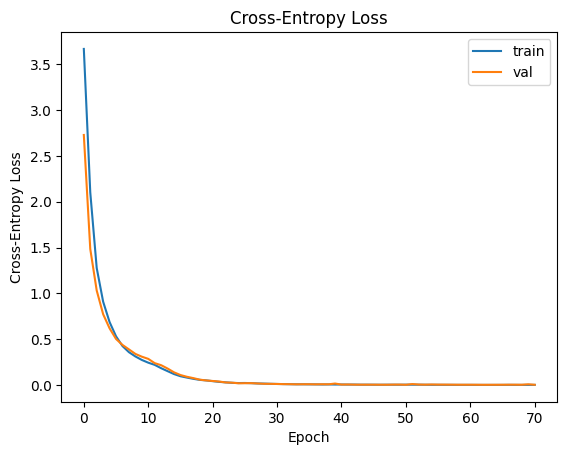

In [20]:
plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'],   label='val')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Cross-Entropy Loss')
plt.legend()

plt.show()

## Evaluation

In [21]:
test_ds     = SymbaSeq2SeqDataset(qed_test, tok, vocab)
test_loader = DataLoader(test_ds, BATCH_SIZE, shuffle=False,
                         collate_fn=_collate, num_workers=0)
print(f'Test batches: {len(test_loader)}')

Normalizing DataFrame Pairs:   0%|          | 0/36 [00:00<?, ?it/s]

Encoding:   0%|          | 0/36 [00:00<?, ?it/s]

Test batches: 2


In [22]:
test_seq_acc, test_tok_acc = evaluate_accuracy(test_loader, n_batches=len(test_loader))
print(f'Test seq acc : {test_seq_acc:.4f}')
print(f'Test tok acc : {test_tok_acc:.4f}')

print()
print(f'{"Split":<10} {"Seq Acc":>8} {"Tok Acc":>8}')
print('-' * 28)
print(f'{"Val":<10} {history["val_seq_acc"]:>8.4f} {history["val_tok_acc"]:>8.4f}')
print(f'{"Test":<10} {test_seq_acc:>8.4f} {test_tok_acc:>8.4f}')

Test seq acc : 0.9167
Test tok acc : 0.9984

Split       Seq Acc  Tok Acc
----------------------------
Val          0.9167   0.9990
Test         0.9167   0.9984
